# 🎮 Video Game Sales Analysis

**Objective:** Perform end-to-end data analysis on the Video Game Sales dataset, covering:
- Data loading & inspection
- Data preprocessing & cleaning
- Exploratory Data Analysis (EDA) with 12 visualizations
- Machine Learning: KNN Classification and Regression models

---

## 📦 Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

print('Libraries imported successfully.')

Libraries imported successfully.


---
## 📂 Load Dataset

In [2]:
df = pd.read_csv('vgsales.csv')
print('Dataset loaded successfully!')
print('Shape:', df.shape)

Dataset loaded successfully!
Shape: (16598, 11)


In [3]:
# Display all column names
print('Column names:', df.columns.tolist())

Column names: ['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


In [4]:
# View Name column (Series)
df['Name']

0                                              Wii Sports
1                                       Super Mario Bros.
2                                          Mario Kart Wii
3                                       Wii Sports Resort
4                                Pokemon Red/Pokemon Blue
                               ...                       
16593                  Woody Woodpecker in Crazy Castle 5
16594                       Men in Black II: Alien Escape
16595    SCORE International Baja 1000: The Official Game
16596                                          Know How 2
16597                                    Spirits & Spells
Name: Name, Length: 16598, dtype: object

In [5]:
# View key columns: Name, Platform, Year, Genre
df[['Name', 'Platform', 'Year', 'Genre']]

,Name,Platform,Year,Genre
0,Wii Sports,Wii,2006.0,Sports
1,Super Mario Bros.,NES,1985.0,Platform
2,Mario Kart Wii,Wii,2008.0,Racing
3,Wii Sports Resort,Wii,2009.0,Sports
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing
...,...,...,...,...
16593,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform
16594,Men in Black II: Alien Escape,GC,2003.0,Shooter
16595,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing
16596,Know How 2,DS,2010.0,Puzzle


---
## 🔍 Data Inspection

### First 5 Rows

In [6]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


### Last 5 Rows

In [7]:
df.tail()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.0,0.0,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.0,0.0,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.0,0.0,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.0,0.0,0.01
16597,16600,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.0,0.0,0.01


### 15 Random Sample Rows

In [8]:
df.sample(15)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
12737,12739,Point Blank DS (US sales),DS,2006.0,Shooter,Atari,0.05,0.00,0.00,0.00,0.06
3150,3152,James Bond 007: Everything or Nothing,XB,2004.0,Shooter,Electronic Arts,0.43,0.19,0.00,0.02,0.64
12856,12858,NFL Quarterback Club 2002,GC,2001.0,Sports,Acclaim Entertainment,0.04,0.01,0.00,0.00,0.05
16067,16070,IL-2 Sturmovik,PC,2001.0,Simulation,Blue Byte,0.00,0.01,0.00,0.00,0.01
12315,12317,Sunrise Eiyuutan R,PS2,2000.0,Role-Playing,Sunrise Interactive,0.00,0.00,0.06,0.00,0.06
2814,2816,Katamari Damacy,PS2,2004.0,Puzzle,Namco Bandai Games,0.47,0.02,0.17,0.08,0.73
325,326,Resident Evil Director's Cut,PS,1996.0,Action,Virgin Interactive,1.82,1.24,0.47,0.25,3.77
5645,5647,Street Fighter Alpha 2,SAT,1995.0,Fighting,Virgin Interactive,0.00,0.00,0.32,0.00,0.32
9099,9101,Gretzky NHL 06,PSP,2005.0,Sports,Sony Computer Entertainment,0.13,0.00,0.00,0.01,0.14
601,602,Sonic Adventure 2 Battle,GC,2001.0,Platform,Sega,1.70,0.59,0.21,0.07,2.56


### Dataset Info — Columns, Data Types, Non-Null Counts

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


### Statistical Summary

In [10]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


### Number of Unique Values per Column

In [11]:
df.nunique()

Rank            16598
Name            11493
Platform           31
Year               39
Genre              12
Publisher         578
NA_Sales          409
EU_Sales          305
JP_Sales          244
Other_Sales       157
Global_Sales      623
dtype: int64

---
## 🧹 Data Preprocessing

### Step 1 — Check for Duplicate Rows

In [12]:
duplicate_value = df.duplicated().sum()
print(f'Number of Duplicate Rows: {duplicate_value}')

Number of Duplicate Rows: 0


### Step 2 — Check for Missing Values

In [13]:
print('Missing values in each column:')
missing_values = df.isnull().sum()
print(missing_values)

Missing values in each column:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


### Step 3 — Inspect Null Rows in Specific Columns

In [14]:
# Rows where Year is null
df[df['Year'].isnull()]

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
179,180,Madden NFL 2004,PS2,NaN,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23
377,378,FIFA Soccer 2004,PS2,NaN,Sports,Electronic Arts,0.59,2.36,0.04,0.51,3.49
431,432,LEGO Batman: The Videogame,Wii,NaN,Action,Warner Bros. Interactive Entertainment,1.86,1.02,0.00,0.29,3.17
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00
607,608,Space Invaders,2600,NaN,Shooter,Atari,2.36,0.14,0.00,0.03,2.53
...,...,...,...,...,...,...,...,...,...,...,...
16307,16310,Freaky Flyers,GC,NaN,Racing,Unknown,0.01,0.00,0.00,0.00,0.01
16327,16330,Inversion,PC,NaN,Shooter,Namco Bandai Games,0.01,0.00,0.00,0.00,0.01
16366,16369,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,Unknown,0.01,0.00,0.00,0.00,0.01
16427,16430,Virtua Quest,GC,NaN,Role-Playing,Unknown,0.01,0.00,0.00,0.00,0.01


In [15]:
# Rows where Publisher is null
df[df['Publisher'].isnull()]

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00
1303,1305,Triple Play 99,PS,NaN,Sports,NaN,0.81,0.55,0.00,0.10,1.46
1662,1664,Shrek / Shrek 2 2-in-1 Gameboy Advance Video,GBA,2007.0,Misc,NaN,0.87,0.32,0.00,0.02,1.21
2222,2224,Bentley's Hackpack,GBA,2005.0,Misc,NaN,0.67,0.25,0.00,0.02,0.93
3159,3161,Nicktoons Collection: Game Boy Advance Video V...,GBA,2004.0,Misc,NaN,0.46,0.17,0.00,0.01,0.64
3166,3168,SpongeBob SquarePants: Game Boy Advance Video ...,GBA,2004.0,Misc,NaN,0.46,0.17,0.00,0.01,0.64
3766,3768,SpongeBob SquarePants: Game Boy Advance Video ...,GBA,2004.0,Misc,NaN,0.38,0.14,0.00,0.01,0.53
4145,4147,Sonic the Hedgehog,PS3,NaN,Platform,NaN,0.00,0.48,0.00,0.00,0.48
4526,4528,The Fairly Odd Parents: Game Boy Advance Video...,GBA,2004.0,Misc,NaN,0.31,0.11,0.00,0.01,0.43
4635,4637,The Fairly Odd Parents: Game Boy Advance Video...,GBA,2004.0,Misc,NaN,0.30,0.11,0.00,0.01,0.42


In [16]:
# Rows where Year OR Publisher is null
df[df['Year'].isnull() | df['Publisher'].isnull()]

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
179,180,Madden NFL 2004,PS2,NaN,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23
377,378,FIFA Soccer 2004,PS2,NaN,Sports,Electronic Arts,0.59,2.36,0.04,0.51,3.49
431,432,LEGO Batman: The Videogame,Wii,NaN,Action,Warner Bros. Interactive Entertainment,1.86,1.02,0.00,0.29,3.17
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00
607,608,Space Invaders,2600,NaN,Shooter,Atari,2.36,0.14,0.00,0.03,2.53
...,...,...,...,...,...,...,...,...,...,...,...
16427,16430,Virtua Quest,GC,NaN,Role-Playing,Unknown,0.01,0.00,0.00,0.00,0.01
16493,16496,The Smurfs,3DS,NaN,Action,Unknown,0.00,0.01,0.00,0.00,0.01
16494,16497,Legends of Oz: Dorothy's Return,3DS,2014.0,Puzzle,NaN,0.00,0.01,0.00,0.00,0.01
16543,16546,Driving Simulator 2011,PC,2011.0,Racing,NaN,0.00,0.01,0.00,0.00,0.01


In [17]:
# Rows where BOTH Year AND Publisher are null
df[df['Year'].isna() & df['Publisher'].isna()]

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00
1303,1305,Triple Play 99,PS,NaN,Sports,NaN,0.81,0.55,0.00,0.10,1.46
4145,4147,Sonic the Hedgehog,PS3,NaN,Platform,NaN,0.00,0.48,0.00,0.00,0.48
5302,5304,Dragon Ball Z: Budokai Tenkaichi 2 (JP sales),Wii,NaN,Action,NaN,0.15,0.05,0.14,0.01,0.35
6272,6274,The Legend of Zelda: The Minish Cap(weekly JP ...,GBA,NaN,Action,NaN,0.00,0.00,0.27,0.01,0.27
7351,7353,Yu Yu Hakusho: Dark Tournament,PS2,NaN,Fighting,NaN,0.10,0.08,0.00,0.03,0.21
9749,9751,Super Robot Wars OG Saga: Masou Kishin II - Re...,PSP,NaN,Strategy,NaN,0.00,0.00,0.12,0.00,0.12
10494,10496,Atsumare! Power Pro Kun no DS Koushien,DS,NaN,Sports,NaN,0.00,0.00,0.10,0.00,0.10
11076,11078,Action Man-Operation Extreme,PS,NaN,Action,NaN,0.05,0.03,0.00,0.01,0.09
12487,12489,Chou Soujuu Mecha MG,DS,NaN,Simulation,NaN,0.00,0.00,0.06,0.00,0.06


In [18]:
# Count of rows where both Year AND Publisher are null
df[df['Year'].isna() & df['Publisher'].isna()].count()

Rank            22
Name            22
Platform        22
Year             0
Genre           22
Publisher        0
NA_Sales        22
EU_Sales        22
JP_Sales        22
Other_Sales     22
Global_Sales    22
dtype: int64

### Step 4 — Drop Rows with Null Year or Publisher

In [19]:
df.dropna(subset=['Year', 'Publisher'], inplace=True)
print('Null values after dropping:')
print(df.isna().sum())

Null values after dropping:
Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16291 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16291 non-null  int64  
 1   Name          16291 non-null  object 
 2   Platform      16291 non-null  object 
 3   Year          16291 non-null  float64
 4   Genre         16291 non-null  object 
 5   Publisher     16291 non-null  object 
 6   NA_Sales      16291 non-null  float64
 7   EU_Sales      16291 non-null  float64
 8   JP_Sales      16291 non-null  float64
 9   Other_Sales   16291 non-null  float64
 10  Global_Sales  16291 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB


### Step 5 — Convert Year Column from Float to Integer

In [21]:
df['Year'] = df['Year'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16291 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16291 non-null  int64  
 1   Name          16291 non-null  object 
 2   Platform      16291 non-null  object 
 3   Year          16291 non-null  int32  
 4   Genre         16291 non-null  object 
 5   Publisher     16291 non-null  object 
 6   NA_Sales      16291 non-null  float64
 7   EU_Sales      16291 non-null  float64
 8   JP_Sales      16291 non-null  float64
 9   Other_Sales   16291 non-null  float64
 10  Global_Sales  16291 non-null  float64
dtypes: float64(5), int32(1), int64(1), object(4)
memory usage: 1.4+ MB


In [22]:
df.head(50)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


### Step 6 — Explore Year Column

In [23]:
print('Minimum Year :', df['Year'].min())
print('Maximum Year :', df['Year'].max())
print('Unique Year Count:', df['Year'].nunique())
print('Unique Years     :', list(df['Year'].unique()))

Minimum Year : 1980
Maximum Year : 2020
Unique Year Count: 39
Unique Years     : [2006, 1985, 2008, 2009, 1996, 1989, 1984, 2005, 1999, 2007, 2010, 2013, 2004, 1990, 1988, 2002, 2001, 2011, 1998, 2015, 2012, 2014, 1992, 1997, 1993, 1994, 1982, 2003, 1986, 2000, 1995, 2016, 1991, 1981, 1987, 1980, 1983, 2020, 2017]


---
## 📊 Exploratory Data Analysis (EDA)

We will explore the dataset through **12 visualizations**, covering sales trends, genre popularity, platform performance, publisher analysis, and regional breakdowns.

### Chart 1 — Global Video Game Sales Trend Over Years

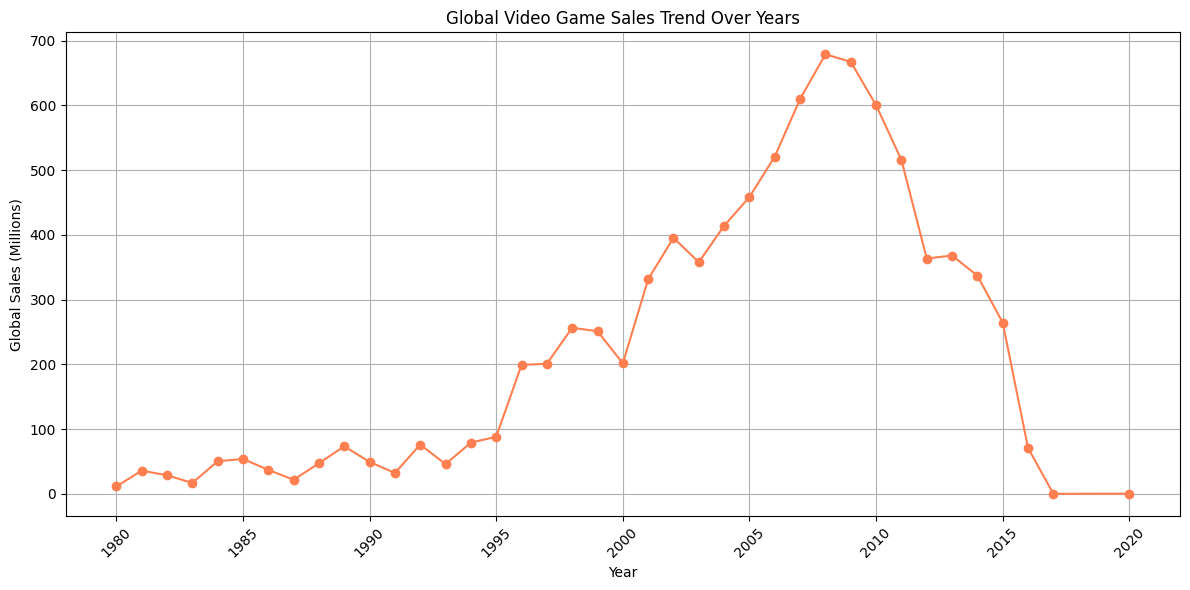

In [24]:
yearly_sales = df.groupby('Year')['Global_Sales'].sum()

plt.figure(figsize=(12, 6))
yearly_sales.plot(marker='o', color='coral')
plt.title('Global Video Game Sales Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Global Sales (Millions)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Chart 2 — Top 10 Games by Global Sales

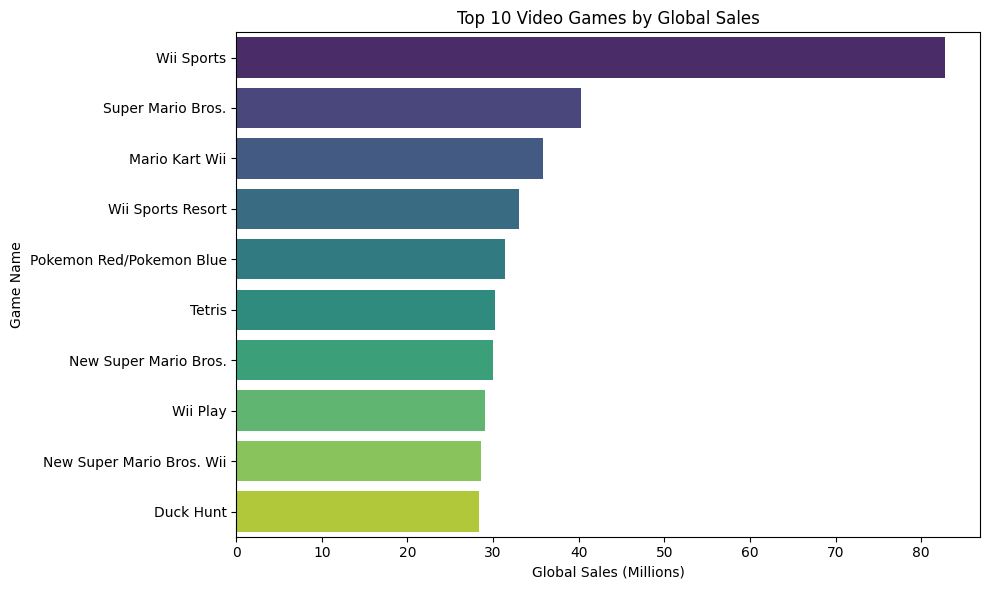

In [25]:
top_10_games = df.nlargest(10, 'Global_Sales')

plt.figure(figsize=(10, 6))
sns.barplot(x='Global_Sales', y='Name', data=top_10_games, palette='viridis')
plt.title('Top 10 Video Games by Global Sales')
plt.xlabel('Global Sales (Millions)')
plt.ylabel('Game Name')
plt.tight_layout()
plt.show()

### Chart 3 — Top 5 Platforms by Total Sales (Pie Chart)

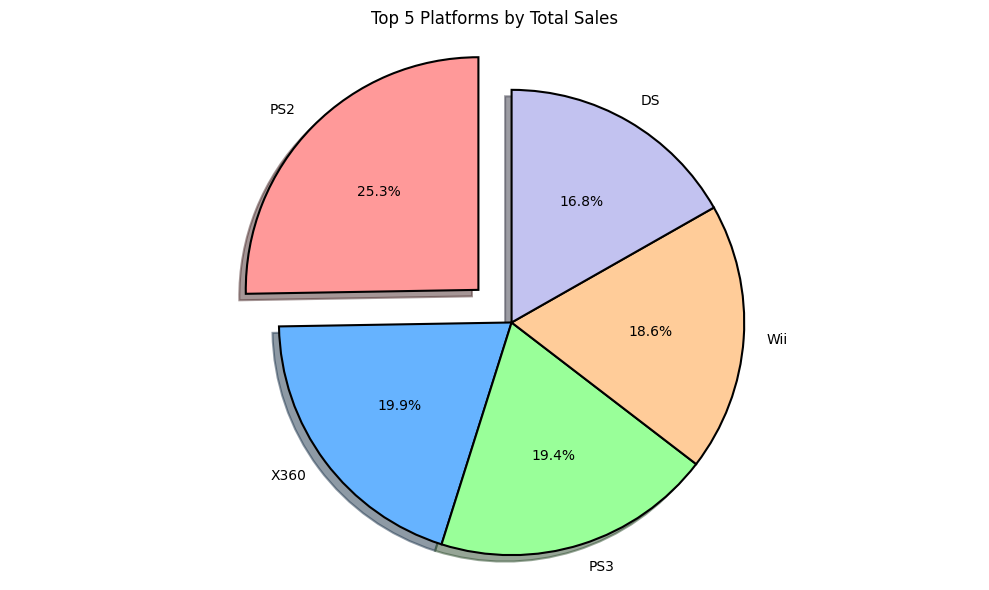

In [26]:
platform_sales = df.groupby('Platform').Global_Sales.sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.pie(
    platform_sales.head(),
    labels=platform_sales.head().index,
    autopct='%1.1f%%',
    colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0'],
    explode=(0.2, 0, 0, 0, 0),
    shadow=True,
    startangle=90,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5}
)
plt.axis('equal')
plt.title('Top 5 Platforms by Total Sales')
plt.tight_layout()
plt.show()

### Chart 4 — Popularity of Game Genres by Global Sales

In [27]:
print('Unique Genres        :', list(df['Genre'].unique()))
print('Number of Genres     :', df['Genre'].nunique())

Unique Genres        : ['Sports', 'Platform', 'Racing', 'Role-Playing', 'Puzzle', 'Misc', 'Shooter', 'Simulation', 'Action', 'Fighting', 'Adventure', 'Strategy']
Number of Genres     : 12


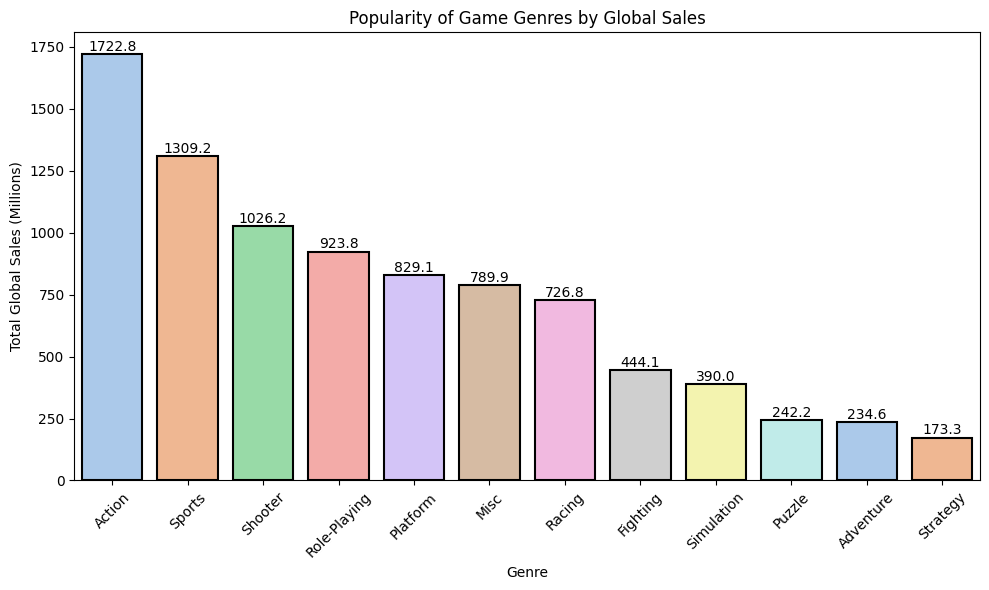

In [28]:
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
genre_sales_df = genre_sales.reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=genre_sales, palette='pastel', edgecolor='black', linewidth=1.5)
for i, row in genre_sales_df.iterrows():
    plt.text(i, row['Global_Sales'] + 0.5, f'{row["Global_Sales"]:.1f}', ha='center', va='bottom')
plt.title('Popularity of Game Genres by Global Sales')
plt.xlabel('Genre')
plt.ylabel('Total Global Sales (Millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Chart 5 — Number of Games by Genre (Count Plot)

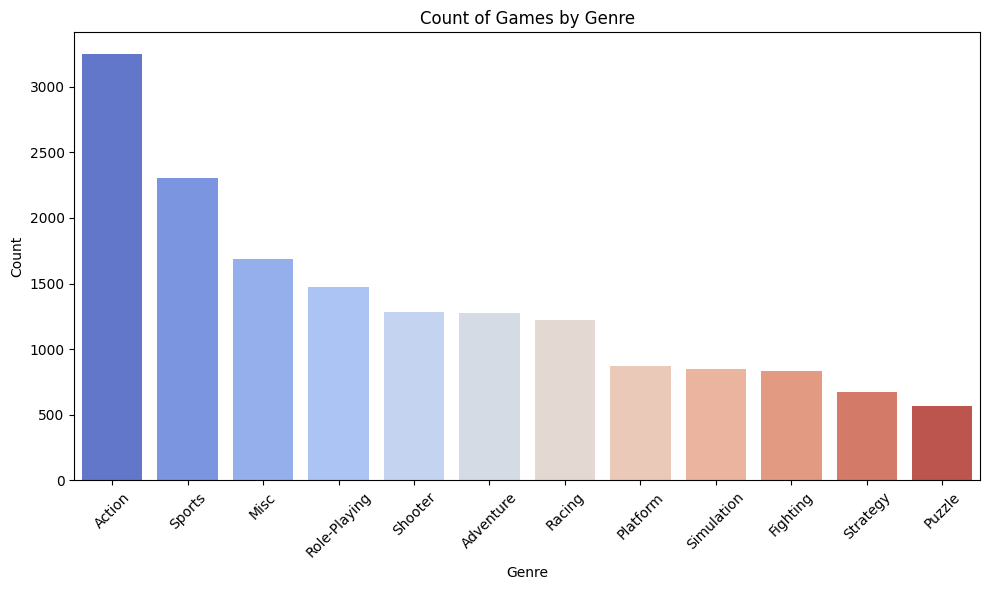

In [29]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Genre', order=df['Genre'].value_counts().index, palette='coolwarm')
plt.title('Count of Games by Genre')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Chart 6 — Top Publishers with Most Games Released

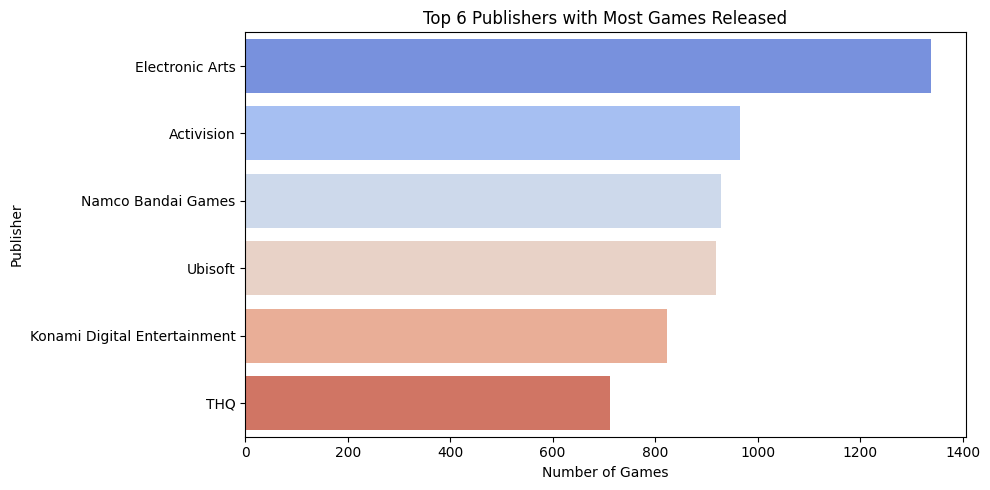

In [30]:
top_publishers = df['Publisher'].value_counts().head(6)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_publishers.values, y=top_publishers.index, palette='coolwarm')
plt.title('Top 6 Publishers with Most Games Released')
plt.xlabel('Number of Games')
plt.ylabel('Publisher')
plt.tight_layout()
plt.show()

### Chart 7 — Top 10 Publishers by Global Sales

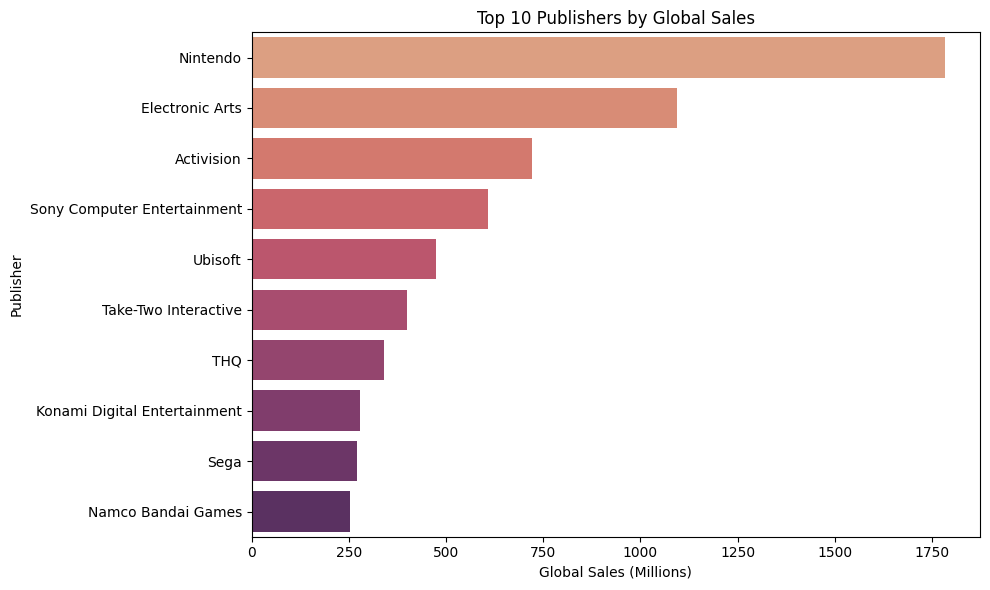

In [31]:
top_publishers = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_publishers.values, y=top_publishers.index, palette='flare')
plt.title('Top 10 Publishers by Global Sales')
plt.xlabel('Global Sales (Millions)')
plt.ylabel('Publisher')
plt.tight_layout()
plt.show()

### Chart 8 — Top Publisher by Region

In [32]:
region_columns = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']

# Find the top publisher by total sales in each region
top_publishers_cleaned = {}
for region in region_columns:
    top_publisher = df.groupby('Publisher')[region].sum().sort_values(ascending=False).head(1)
    top_publishers_cleaned[region] = top_publisher

# Create a summary DataFrame
top_publishers_df_cleaned = pd.DataFrame({
    'Region': list(top_publishers_cleaned.keys()),
    'Top Publisher': [p.idxmax() for p in top_publishers_cleaned.values()],
    'Sales (in Millions)': [p.max() for p in top_publishers_cleaned.values()]
})

print(top_publishers_df_cleaned)

        Region    Top Publisher  Sales (in Millions)
0     NA_Sales         Nintendo               815.75
1     EU_Sales         Nintendo               418.30
2     JP_Sales         Nintendo               454.99
3  Other_Sales  Electronic Arts               127.63


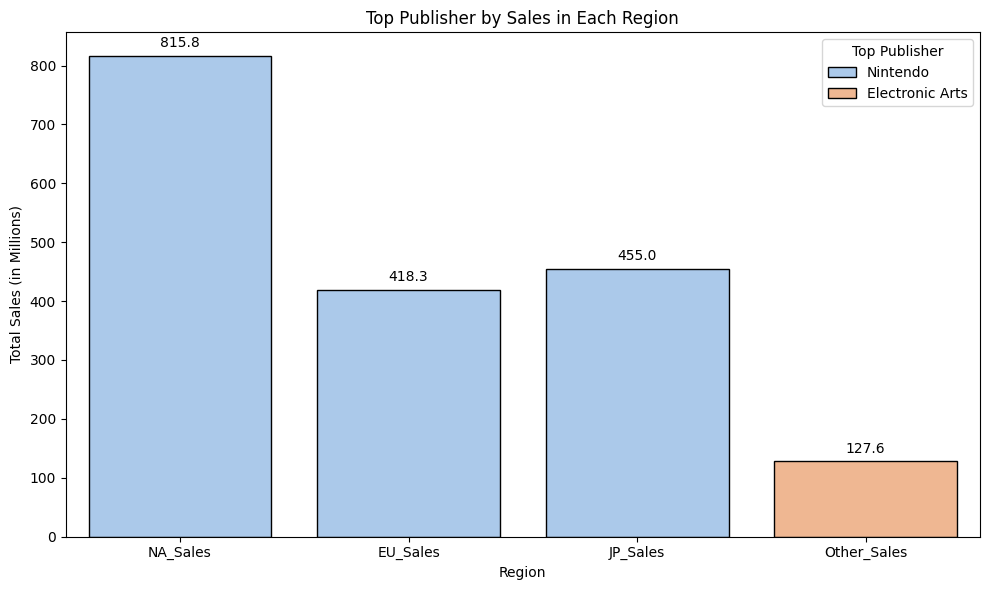

In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Region',
    y='Sales (in Millions)',
    hue='Top Publisher',
    data=top_publishers_df_cleaned,
    palette='pastel',
    edgecolor='black'
)
for i, row in top_publishers_df_cleaned.iterrows():
    plt.text(i, row['Sales (in Millions)'] + 10,
             f'{row["Sales (in Millions)"]:.1f}',
             ha='center', va='bottom', fontsize=10)
plt.title('Top Publisher by Sales in Each Region')
plt.ylabel('Total Sales (in Millions)')
plt.xlabel('Region')
plt.tight_layout()
plt.show()

### Chart 9 — Sales Trends by Genre Over Time (Heatmap)

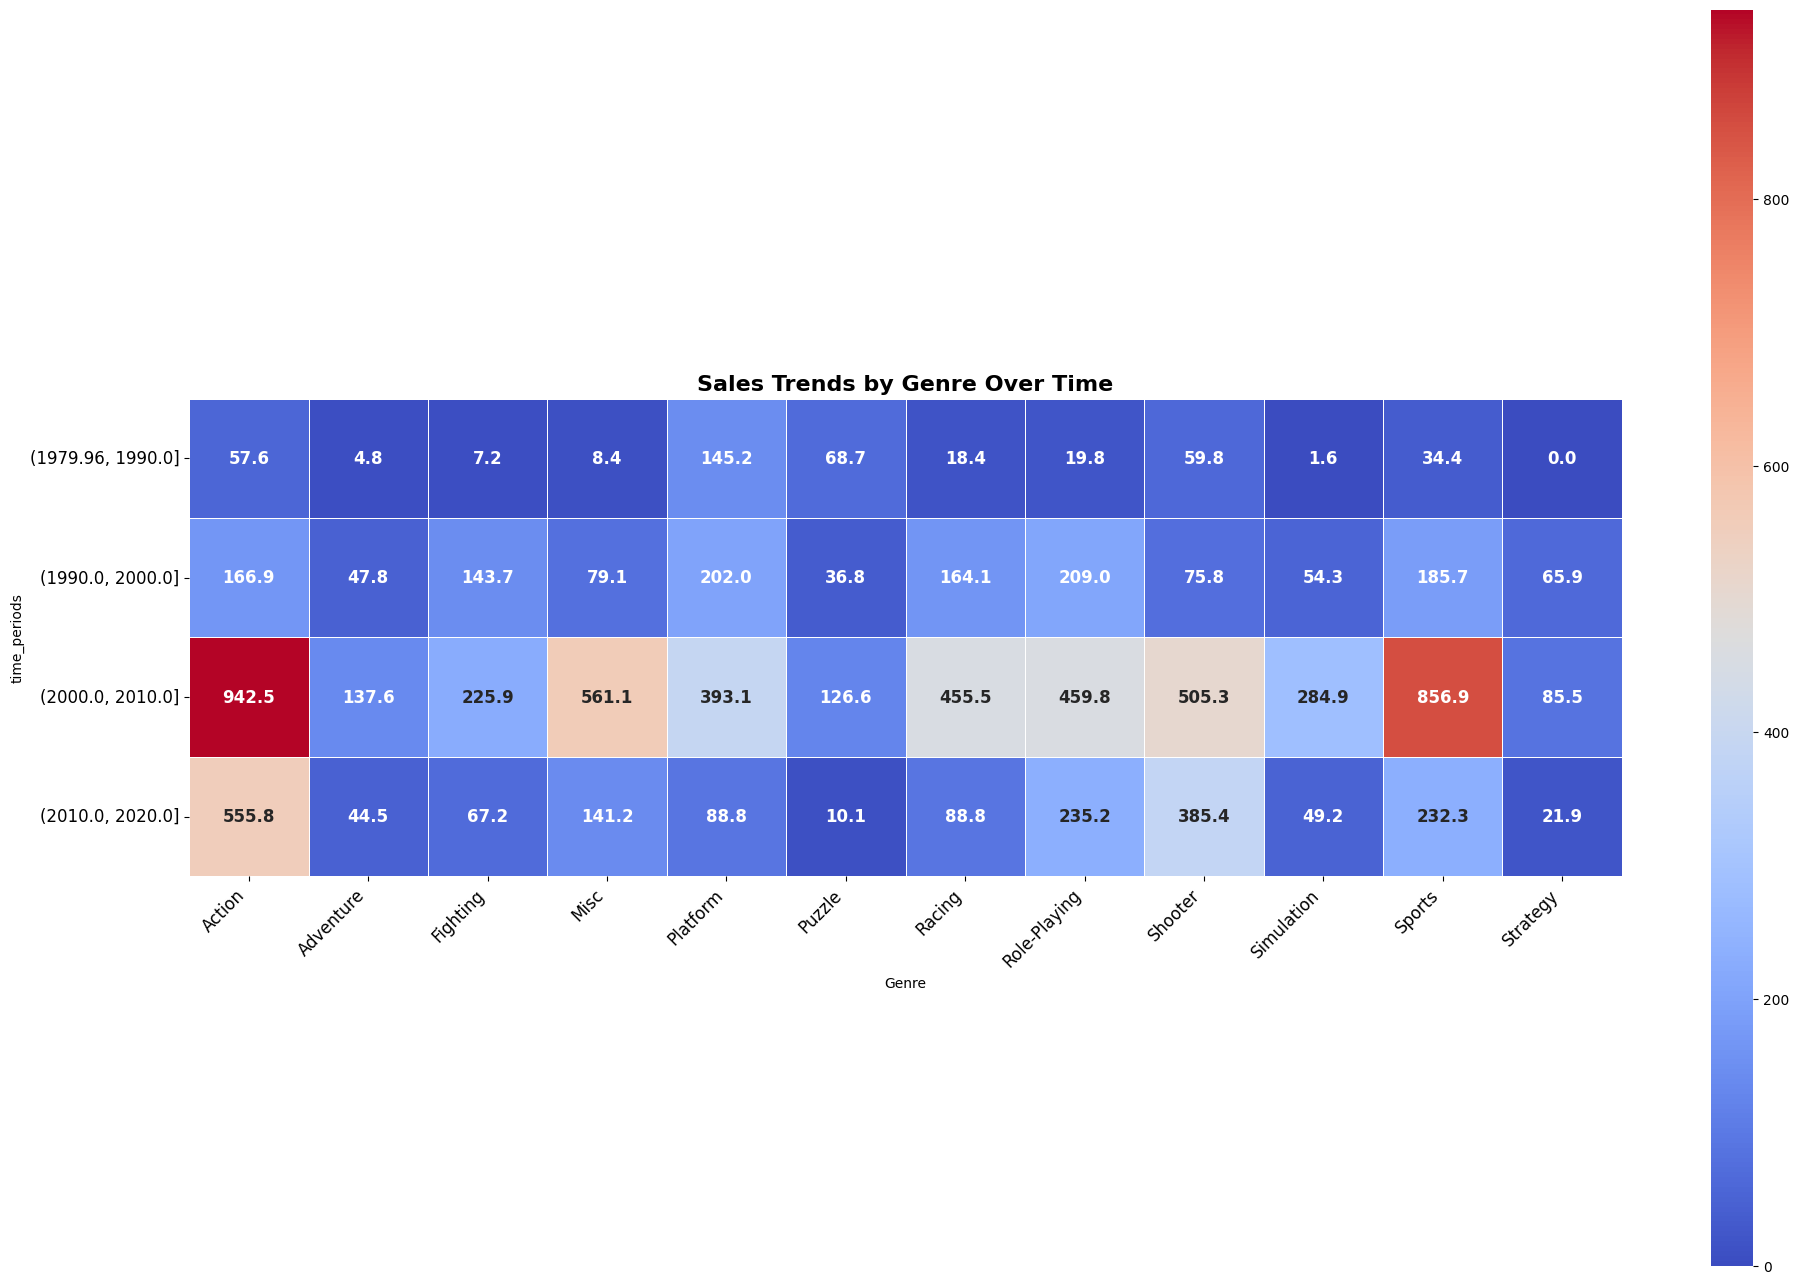

In [34]:
df['time_periods'] = pd.cut(df.Year, bins=4)
df_time_sales = df.groupby(['time_periods', 'Genre']).Global_Sales.sum().reset_index()
df_time_sales = df_time_sales.pivot(
    index='time_periods',
    columns='Genre',
    values='Global_Sales'
)

plt.figure(figsize=(20, 16))
sns.heatmap(
    df_time_sales,
    cmap='coolwarm',
    linewidths=0.5,
    annot=True,
    fmt='.1f',
    annot_kws={'size': 12, 'weight': 'bold'},
    cbar_kws={'shrink': 0.8, 'aspect': 30},
    square=True
)
plt.title('Sales Trends by Genre Over Time', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

### Chart 10 — Correlation Between Regional and Global Sales

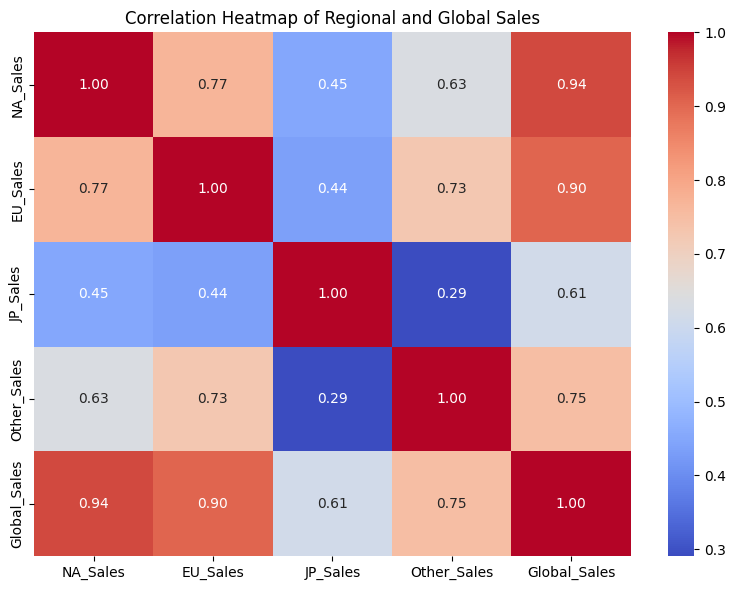

In [35]:
corr = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Regional and Global Sales')
plt.tight_layout()
plt.show()

### Chart 11 — Publisher Sales Trends Over Time (Top 3 Publishers)

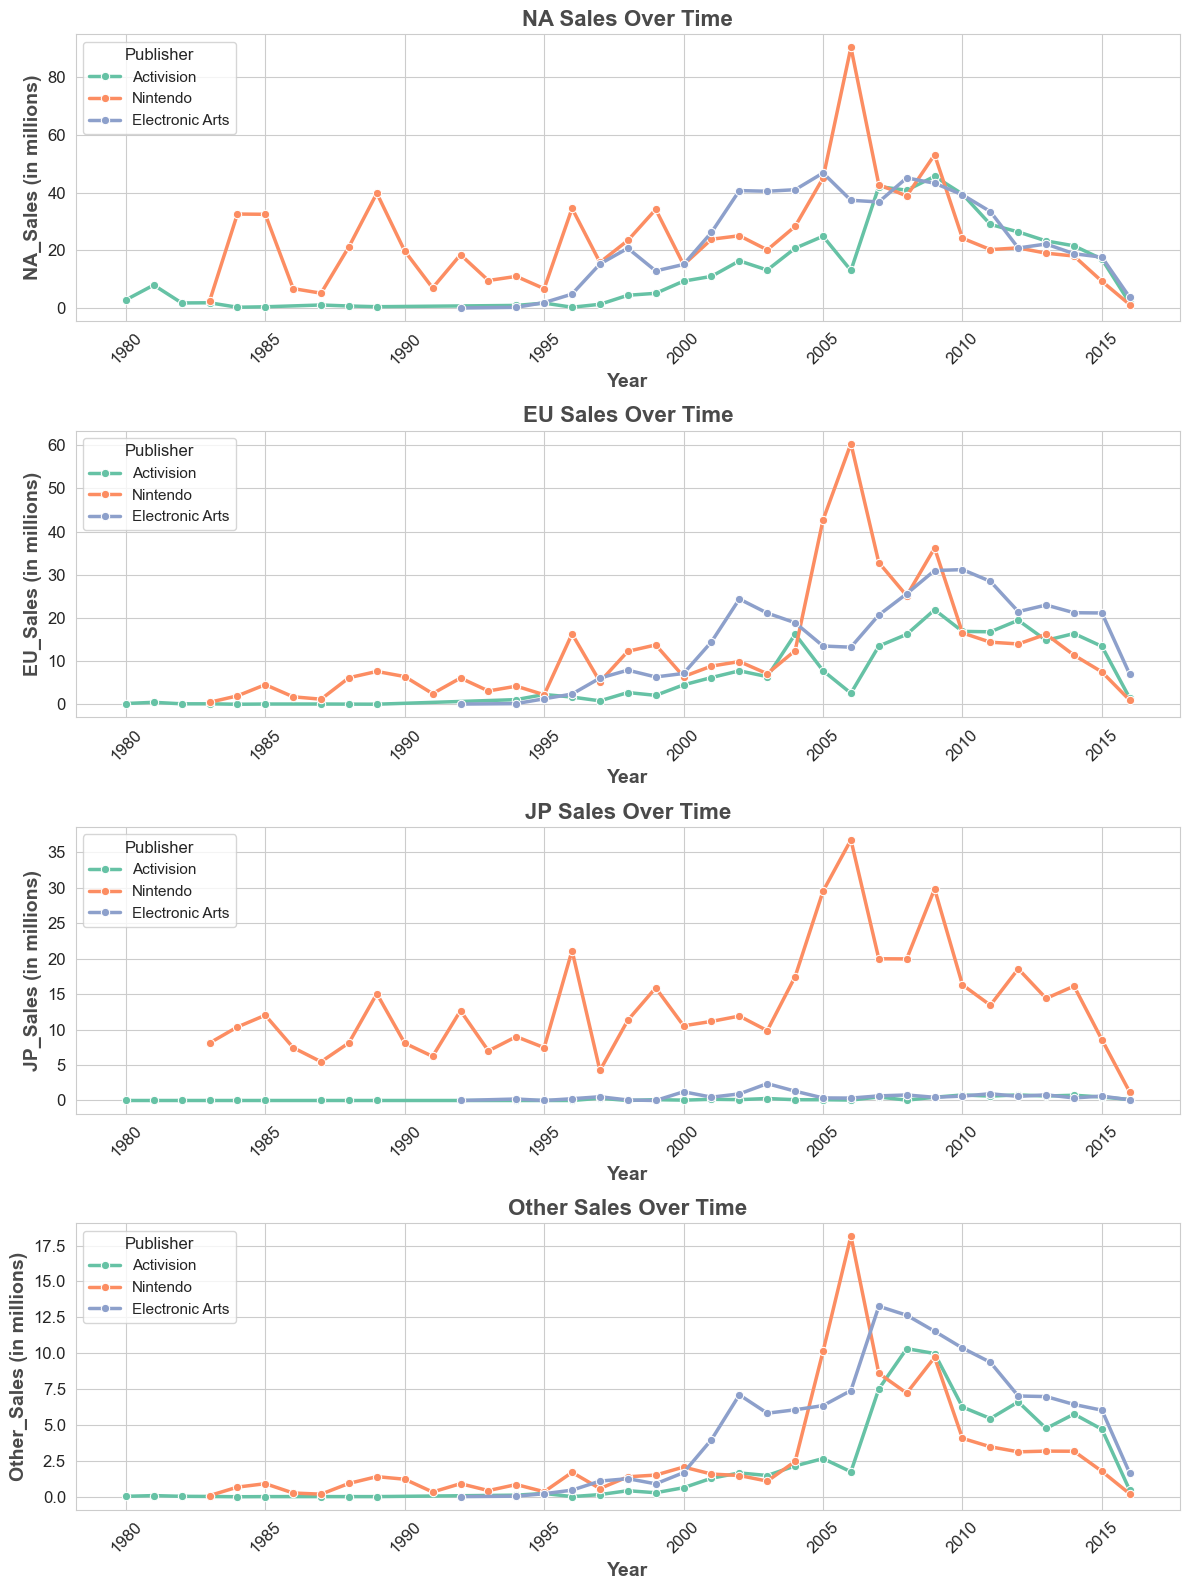

In [36]:
# Get the top 3 publishers by overall global sales
successful_publishers = df.groupby('Publisher').Global_Sales.sum().sort_values(ascending=False).index.to_list()
top3_publishers = successful_publishers[:3]

df_top3 = (
    df[df['Publisher'].isin(top3_publishers)]
    .groupby(['Year', 'Publisher'])[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']]
    .sum()
    .reset_index()
)

sales_columns = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
titles = ['NA Sales Over Time', 'EU Sales Over Time', 'JP Sales Over Time', 'Other Sales Over Time']

plt.figure(figsize=(12, 16))
sns.set_style('whitegrid')
for i, (col, title) in enumerate(zip(sales_columns, titles), start=1):
    plt.subplot(4, 1, i)
    sns.lineplot(x='Year', y=col, data=df_top3, hue='Publisher',
                 marker='o', linewidth=2.5, palette='Set2')
    plt.title(title, fontsize=16, fontweight='bold', color='#4a4a4a')
    plt.xlabel('Year', fontsize=14, fontweight='bold', color='#4a4a4a')
    plt.ylabel(f'{col} (in millions)', fontsize=14, fontweight='bold', color='#4a4a4a')
    plt.legend(title='Publisher', title_fontsize=12, fontsize=11, loc='upper left', frameon=True)
    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

### Chart 12 — Platform-wise Sales Distribution (Boxplot)

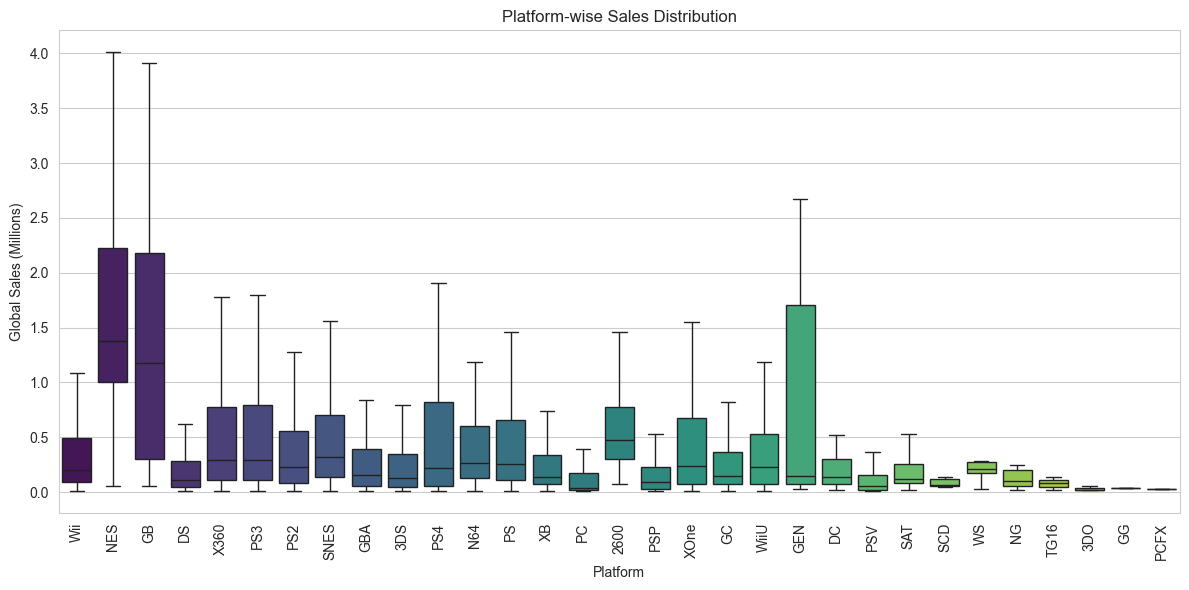

In [37]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Platform', y='Global_Sales', data=df, showfliers=False, palette='viridis')
plt.xticks(rotation=90)
plt.title('Platform-wise Sales Distribution')
plt.xlabel('Platform')
plt.ylabel('Global Sales (Millions)')
plt.tight_layout()
plt.show()

---
## 🤖 Machine Learning

We will build **two types** of models:
1. **KNN Classification** — Predict whether a game is a *Hit* (Global Sales > 1M) or *Not Hit*
2. **Linear Regression & KNN Regression** — Predict the actual *Global Sales* value

### ML Part 1 — KNN Classification: Hit or Not Hit?

In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

In [39]:
# Create binary target: 1 if Global Sales > 1 million (Hit), else 0 (Not Hit)
df['Hit'] = (df['Global_Sales'] > 1).astype(int)

print('Class distribution:')
print(df['Hit'].value_counts())
print(f'\nHit games     : {df["Hit"].sum()}')
print(f'Non-hit games : {(df["Hit"] == 0).sum()}')

Class distribution:
Hit
0    14260
1     2031
Name: count, dtype: int64

Hit games     : 2031
Non-hit games : 14260


In [40]:
# Define features and target
features = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
X_cls = df[features]
y_cls = df['Hit']

# Train-test split (80% train, 20% test)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

print('Training size :', Xc_train.shape[0])
print('Testing size  :', Xc_test.shape[0])

Training size : 13032
Testing size  : 3259


In [41]:
# Scale features (important for KNN)
scaler_cls = StandardScaler()
Xc_train_scaled = scaler_cls.fit_transform(Xc_train)
Xc_test_scaled  = scaler_cls.transform(Xc_test)

In [42]:
# Initialize and train KNN Classifier (k=5)
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(Xc_train_scaled, yc_train)

# Predictions
yc_pred = knn_classifier.predict(Xc_test_scaled)

In [43]:
# Evaluate the classifier
print('=== KNN Classifier — Classification Report ===')
print(classification_report(yc_test, yc_pred))
print(f'Overall Accuracy: {accuracy_score(yc_test, yc_pred) * 100:.2f}%')

=== KNN Classifier — Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2880
           1       0.98      0.98      0.98       379

    accuracy                           1.00      3259
   macro avg       0.99      0.99      0.99      3259
weighted avg       1.00      1.00      1.00      3259

Overall Accuracy: 99.60%


---
### ML Part 2 — Linear Regression & KNN Regression: Predict Global Sales

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [45]:
# Define features and target
feature_cols = ['Platform', 'Genre', 'Publisher', 'Year',
                'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']

# Encode categorical variables using LabelEncoder
label_encoders = {}
categorical_features = ['Platform', 'Genre', 'Publisher']
for feature in categorical_features:
    le = LabelEncoder()
    df[feature] = le.fit_transform(df[feature])
    label_encoders[feature] = le

X = df[feature_cols]
y = df['Global_Sales']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training size :', X_train.shape[0])
print('Testing size  :', X_test.shape[0])

Training size : 13032
Testing size  : 3259


#### Linear Regression

In [46]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

lin_rmse = mean_squared_error(y_test, y_pred_lin, squared=False)
lin_r2   = r2_score(y_test, y_pred_lin)

print('=== Linear Regression Performance ===')
print(f'  RMSE : {lin_rmse:.4f}')
print(f'  R²   : {lin_r2:.4f}')

=== Linear Regression Performance ===
  RMSE : 0.0054
  R²   : 1.0000


#### KNN Regression

In [47]:
# Scale features for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_scaled, y_train)
y_pred_knn = knn_reg.predict(X_test_scaled)

knn_rmse = mean_squared_error(y_test, y_pred_knn, squared=False)
knn_r2   = r2_score(y_test, y_pred_knn)

print('=== KNN Regression Performance ===')
print(f'  RMSE : {knn_rmse:.4f}')
print(f'  R²   : {knn_r2:.4f}')

=== KNN Regression Performance ===
  RMSE : 0.9839
  R²   : 0.7737


#### Model Comparison Summary

In [48]:
model_performance = pd.DataFrame({
    'Model'   : ['Linear Regression', 'KNN Regression'],
    'RMSE'    : [lin_rmse, knn_rmse],
    'R2 Score': [lin_r2,   knn_r2]
})
print(model_performance.to_string(index=False))

            Model     RMSE  R2 Score
Linear Regression 0.005356  0.999993
   KNN Regression 0.983930  0.773697


#### Visualization — RMSE Comparison

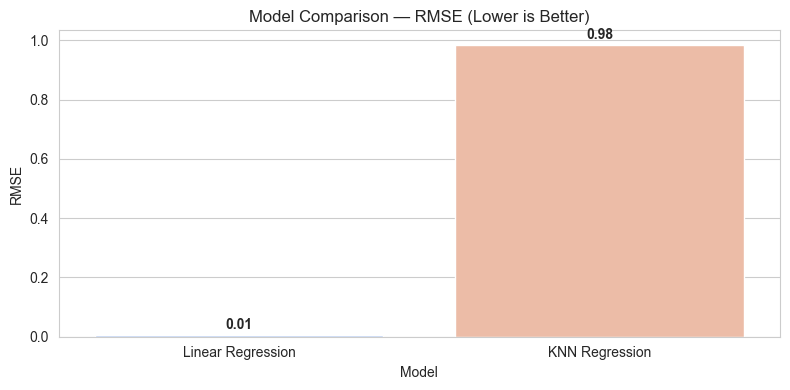

In [49]:
plt.figure(figsize=(8, 4))
sns.barplot(x='Model', y='RMSE', data=model_performance, palette='coolwarm')
plt.title('Model Comparison — RMSE (Lower is Better)')
for i, row in model_performance.iterrows():
    plt.text(i, row.RMSE + 0.02, f'{row.RMSE:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

#### Visualization — R² Score Comparison

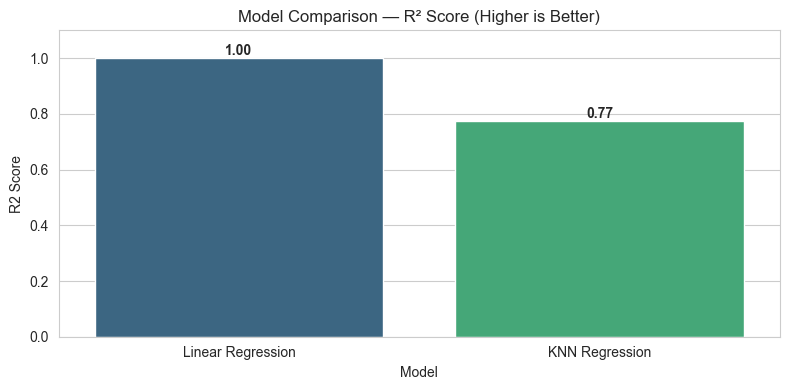

In [50]:
plt.figure(figsize=(8, 4))
sns.barplot(x='Model', y='R2 Score', data=model_performance, palette='viridis')
plt.title('Model Comparison — R² Score (Higher is Better)')
for i, row in model_performance.iterrows():
    plt.text(i, row['R2 Score'] + 0.01, f'{row["R2 Score"]:.2f}', ha='center', fontweight='bold')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

#### Visualization — Actual vs. Predicted (Linear Regression)

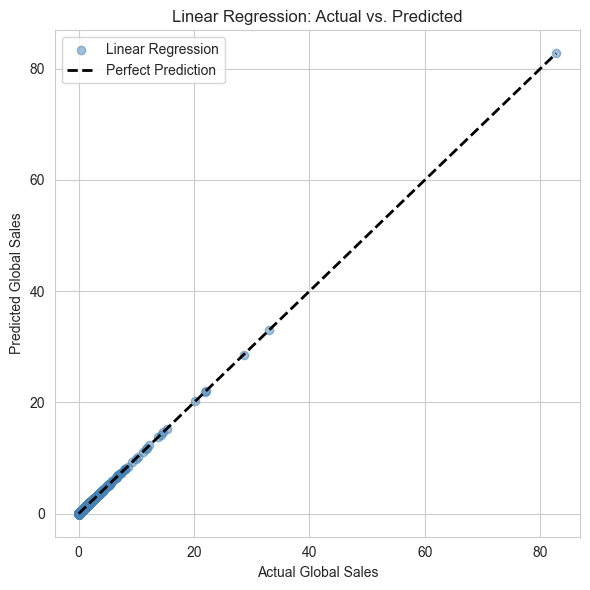

In [51]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_lin, alpha=0.5, color='steelblue', label='Linear Regression')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Global Sales')
plt.ylabel('Predicted Global Sales')
plt.title('Linear Regression: Actual vs. Predicted')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Visualization — Actual vs. Predicted (KNN Regression)

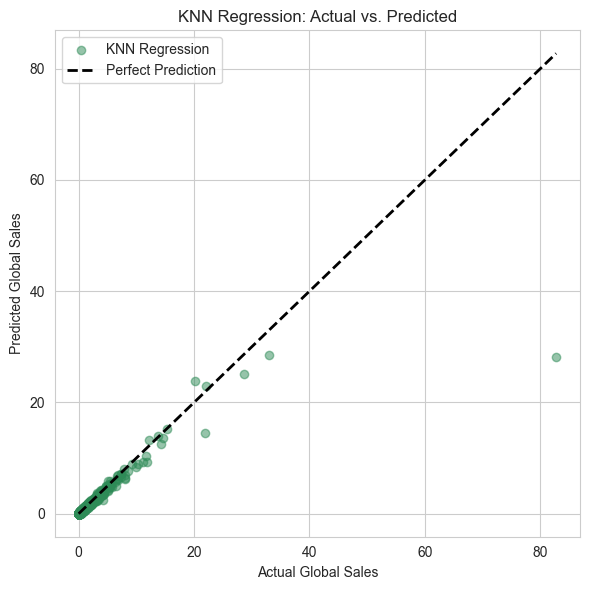

In [52]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_knn, alpha=0.5, color='seagreen', label='KNN Regression')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Global Sales')
plt.ylabel('Predicted Global Sales')
plt.title('KNN Regression: Actual vs. Predicted')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---
## ✅ Summary

| Section | Key Findings |
|---|---|
| **EDA** | Video game sales peaked around 2008–2009, with Action being the most popular genre |
| **Platform** | PS2, X360, and PS3 dominated global sales |
| **Publishers** | Nintendo leads in both number of games released and global sales |
| **KNN Classifier** | Classifies games as 'Hit' or 'Not Hit' based on regional sales |
| **Regression** | Both Linear Regression and KNN Regression used to predict global sales |